# La corriente que mueve el calor del planeta se está apagando — y el Océano Sur se adelantó

1.300 años escondidos en corales de aguas profundas. Y lo que dicen no es tranquilizador.

---

**Paper:** Thresher, R. et al. (2026). *Millennial-scale Atlantic overturning circulation led by the Southern Ocean.* Nature Geoscience.
**DOI:** [10.1038/s41561-026-01959-6](https://doi.org/10.1038/s41561-026-01959-6)
**Datos:** [CSIRO Data Collection](https://doi.org/10.25919/9dqy-2x95) + [GitHub (AMOC Analysis)](https://github.com/ncahill89/AMOC-Analysis)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-06-circulacion-atlantico-oceano-sur/notebook.ipynb)

## La cinta transportadora oceánica

La circulación meridional de vuelco (AMOC, por sus siglas en inglés) es la gran cinta transportadora del océano: mueve calor, carbono y nutrientes entre hemisferios. Si se debilita, Europa se enfría, los monzones se desplazan y el nivel del mar sube de forma desigual.

Sabemos que se ha debilitado en las últimas décadas, pero los registros instrumentales son cortos (~20 años). ¿Cómo saber si esto es normal?

Un equipo australiano encontró la forma de mirar más atrás: analizó la química de **corales bambú de aguas profundas** del Pacífico suroeste, que registran la temperatura del Agua Intermedia Antártica (AAIW) como un termómetro natural. El ratio Mg/Ca en su calcita crece con la temperatura del agua intermedia — y más temperatura indica más circulación.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PERIODO_MEDIEVAL = (900, 1200)     # Anomalía Climática Medieval
PERIODO_MODERNO = 1900             # Inicio era moderna
PERIODO_RECIENTE = 1990            # Últimas dos décadas de datos
COLOR_SO = '#2563EB'               # Azul — Océano Sur
COLOR_NA = '#DC2626'               # Rojo — Atlántico Norte
COLOR_REF = '#D97706'              # Ámbar — referencia
COLOR_SEC = '#059669'              # Emerald — secundario
FUENTE = 'Fuente: Thresher et al. (2026), Nat. Geosci. | Datos: CSIRO + GitHub (AMOC Analysis)'

# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os, urllib.request

# ── Estilo CaM ──
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Datos ──
# Proxy Océano Sur (AAIW Mg/Ca — corales bambú, 698-2011 CE)
df_so = pd.read_csv('datos/aaiw_proxy_mgca.csv')
# Proxy Atlántico Norte (Rahmstorf et al. 2015 — SST AMOC index, 900-1995 CE)
df_na = pd.read_csv('datos/rahmstorf_amoc_index.csv')
# Proxy AMOC moderno (Caesar et al. 2018 — 1871-2016 CE)
df_caesar = pd.read_csv('datos/caesar_amoc_proxy.csv')

print(f"Proxy Océano Sur: {len(df_so):,} puntos ({df_so['year_ce'].min():.0f}–{df_so['year_ce'].max():.0f} CE)")
print(f"Proxy AMOC (Rahmstorf): {len(df_na):,} puntos ({df_na['year_ce'].min():.0f}–{df_na['year_ce'].max():.0f} CE)")
print(f"Proxy AMOC moderno (Caesar): {len(df_caesar):,} puntos ({df_caesar['year_ce'].min():.0f}–{df_caesar['year_ce'].max():.0f} CE)")

Proxy Océano Sur: 1,038 puntos (698–2011 CE)
Proxy AMOC (Rahmstorf): 1,096 puntos (900–1995 CE)
Proxy AMOC moderno (Caesar): 146 puntos (1871–2016 CE)


## 1.300 años en una gráfica

Aquí está.

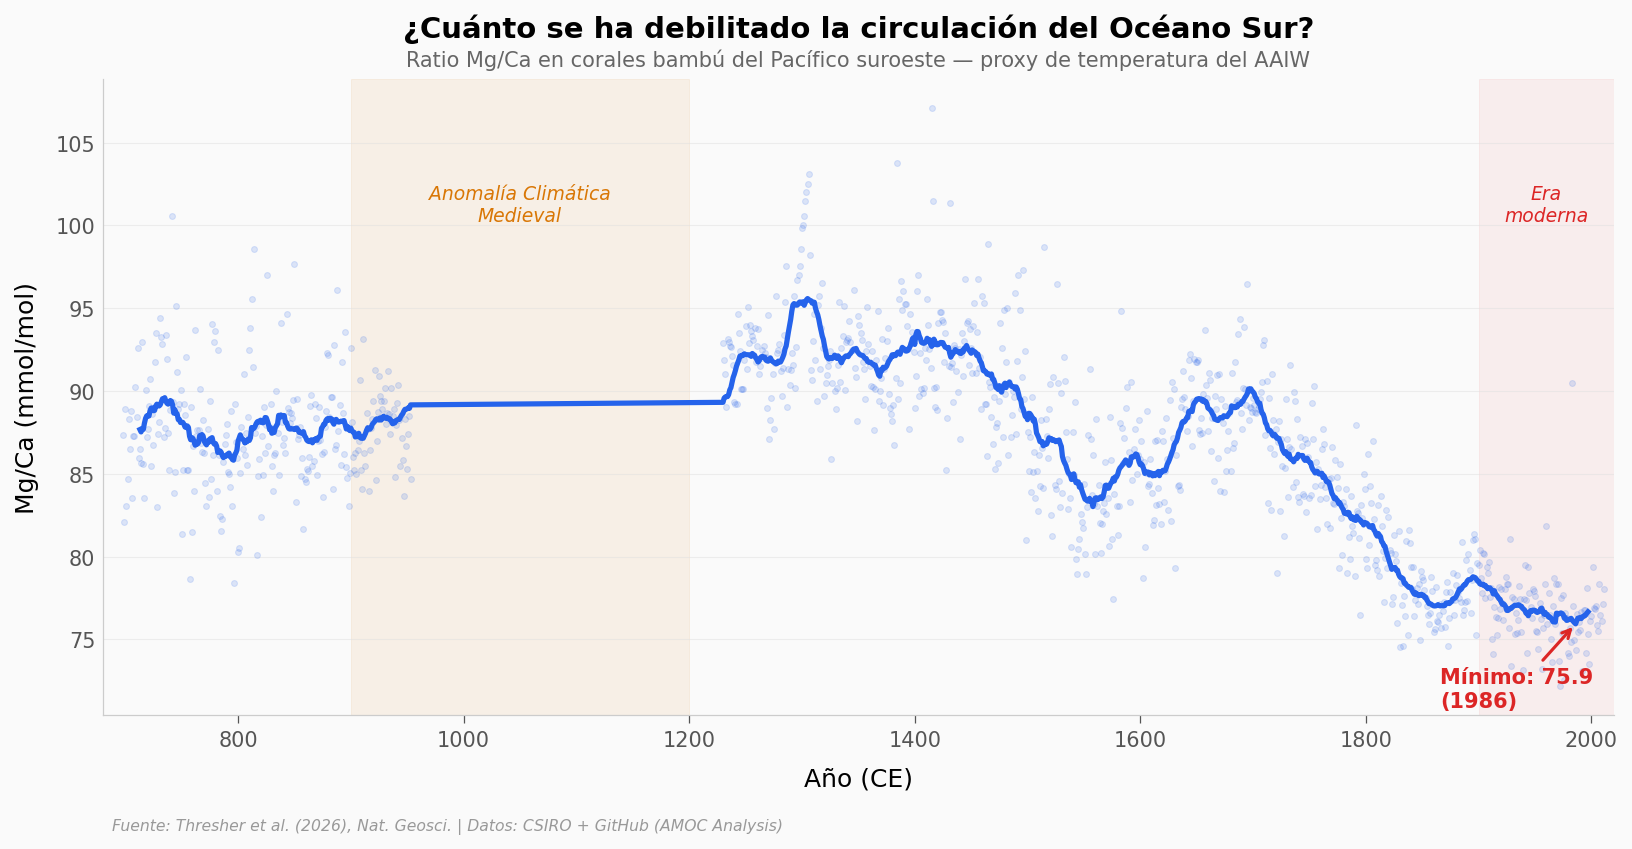

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Rolling 30-year average for trend
df_so_sorted = df_so.sort_values('year_ce')
rolling = df_so_sorted['mgca_mmol_mol'].rolling(30, center=True).mean()

# Raw data (light)
ax.scatter(df_so_sorted['year_ce'], df_so_sorted['mgca_mmol_mol'],
           color=COLOR_SO, s=8, alpha=0.15, zorder=3)

# Rolling average (bold)
ax.plot(df_so_sorted['year_ce'], rolling,
        color=COLOR_SO, linewidth=2.5, zorder=4, label='Media móvil 30 años')

# Medieval Warm Period
ax.axvspan(*PERIODO_MEDIEVAL, color=COLOR_REF, alpha=0.08, zorder=1)
ax.text(1050, 100, 'Anomalía Climática\nMedieval', fontsize=9, color=COLOR_REF,
        ha='center', va='bottom', style='italic')

# Modern era
ax.axvspan(PERIODO_MODERNO, 2020, color=COLOR_NA, alpha=0.06, zorder=1)
ax.text(1960, 100, 'Era\nmoderna', fontsize=9, color=COLOR_NA,
        ha='center', va='bottom', style='italic')

# Minimum marker
min_idx = df_so_sorted['mgca_mmol_mol'].rolling(30, center=True).mean().idxmin()
if pd.notna(min_idx):
    min_year = df_so_sorted.loc[min_idx, 'year_ce']
    min_val = rolling.loc[min_idx]
    ax.annotate(f'Mínimo: {min_val:.1f}\n({min_year:.0f})',
                xy=(min_year, min_val), xytext=(min_year - 120, min_val - 5),
                fontsize=10, fontweight='bold', color=COLOR_NA,
                arrowprops=dict(arrowstyle='->', color=COLOR_NA, lw=1.5))

ax.set_title('¿Cuánto se ha debilitado la circulación del Océano Sur?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Ratio Mg/Ca en corales bambú del Pacífico suroeste — proxy de temperatura del AAIW',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Año (CE)')
ax.set_ylabel('Mg/Ca (mmol/mol)')
ax.set_xlim(680, 2020)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/aaiw_proxy_1300_years.png', dpi=200, bbox_inches='tight')
plt.show()

La tendencia descendente es clara. Durante el período medieval (900–1200 CE), el Mg/Ca promediaba 87,8 mmol/mol. Hoy ronda los 76,8 — una caída del 12,5% respecto al período medieval (Cohen's d = 4,83, efecto enorme).

Pero la caída no fue uniforme. Hubo episodios de recuperación parcial y descensos abruptos. Lo que sí es claro: el mínimo absoluto de los 1.300 años ocurrió en **1972** — dentro de nuestra era.

La media moderna (76,8 mmol/mol) se ubica en el **percentil 8** de toda la serie. Traducción: en el 92% de los últimos 1.313 años, la circulación del Océano Sur fue más fuerte que ahora.

## ¿Qué pasa en el Atlántico Norte?

Si el Océano Sur se apaga, ¿qué hace la AMOC del otro lado del planeta? Veamos los dos registros juntos.

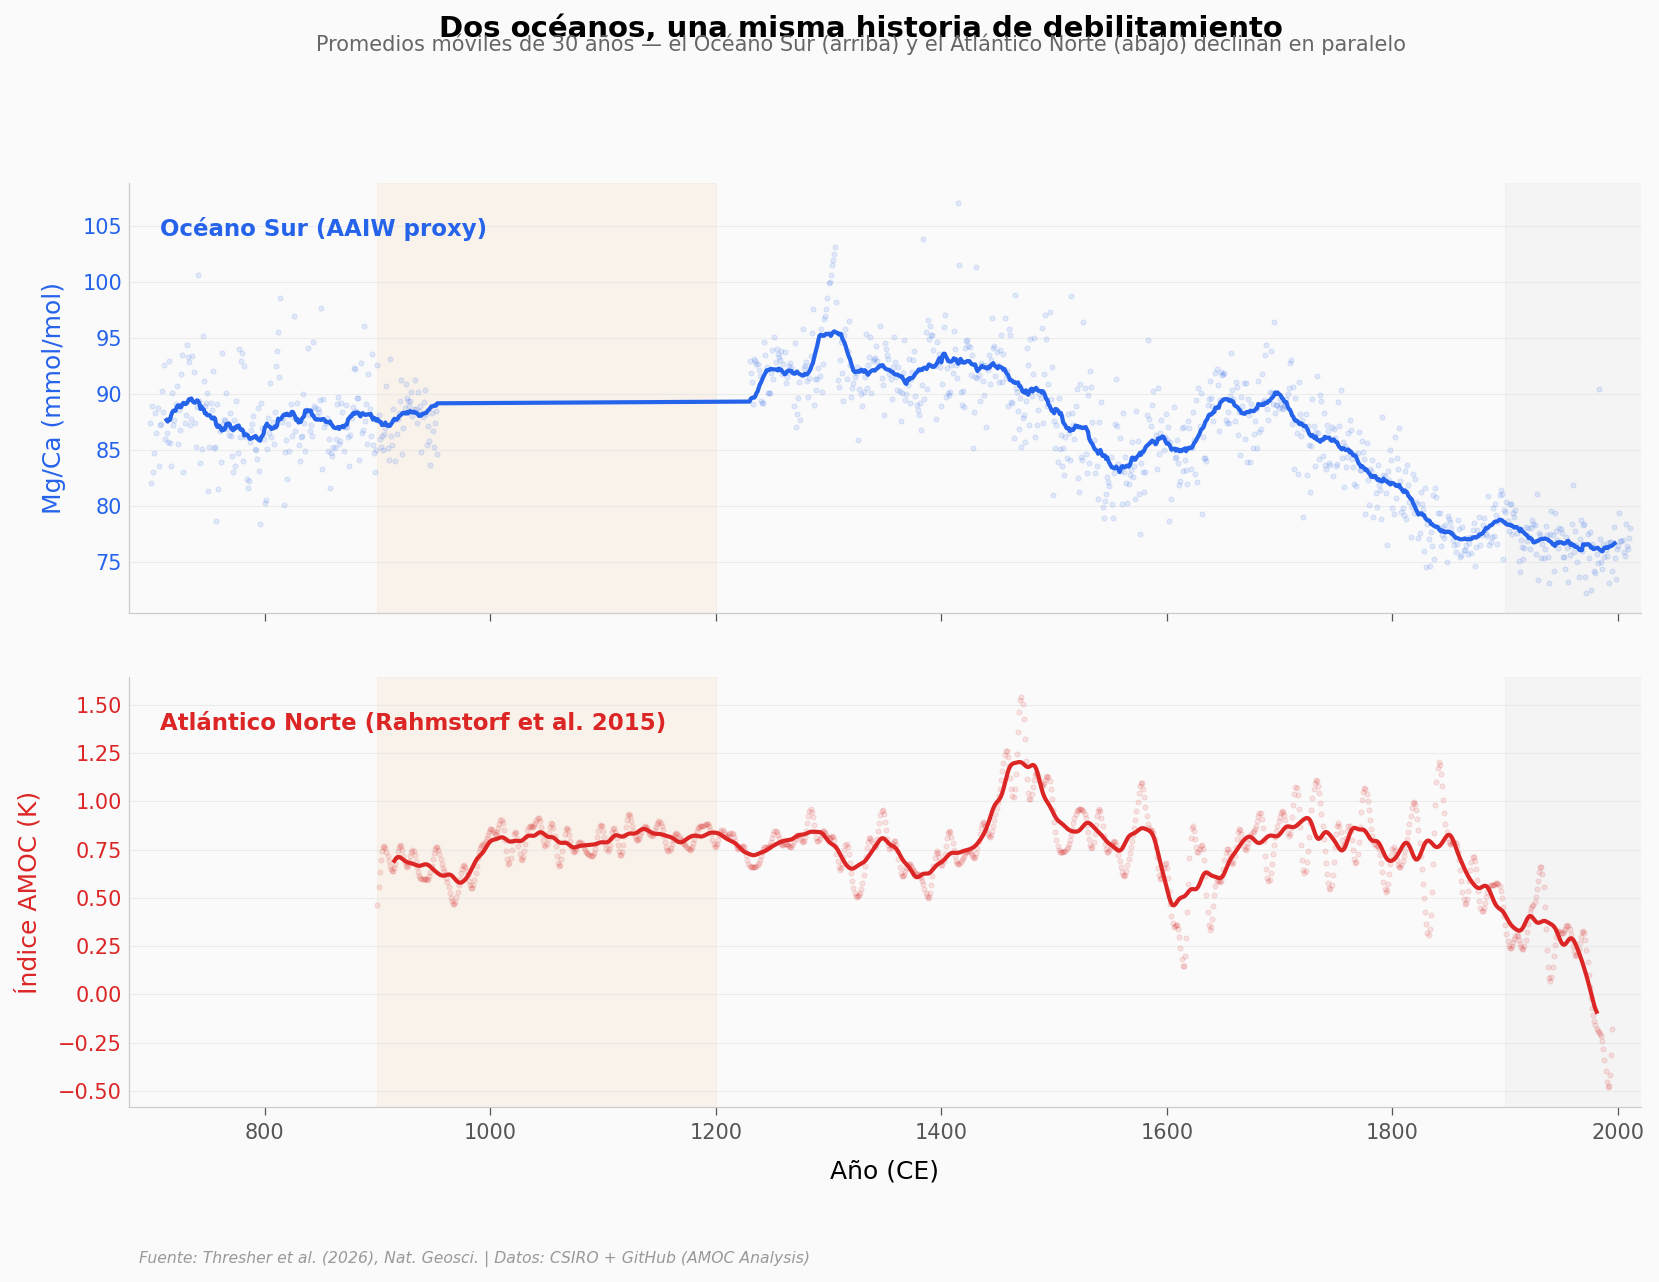

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                               gridspec_kw={'hspace': 0.15})

# ── Panel superior: Océano Sur ──
df_so_s = df_so.sort_values('year_ce')
rolling_so = df_so_s['mgca_mmol_mol'].rolling(30, center=True).mean()
ax1.scatter(df_so_s['year_ce'], df_so_s['mgca_mmol_mol'],
            color=COLOR_SO, s=6, alpha=0.12, zorder=3)
ax1.plot(df_so_s['year_ce'], rolling_so,
         color=COLOR_SO, linewidth=2, zorder=4)
ax1.set_ylabel('Mg/Ca (mmol/mol)', color=COLOR_SO)
ax1.text(0.02, 0.92, 'Océano Sur (AAIW proxy)', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', color=COLOR_SO, va='top')
ax1.tick_params(axis='y', colors=COLOR_SO)

# ── Panel inferior: Atlántico Norte ──
df_na_s = df_na.sort_values('year_ce')
rolling_na = df_na_s['amoc_index_k'].rolling(30, center=True).mean()
ax2.scatter(df_na_s['year_ce'], df_na_s['amoc_index_k'],
            color=COLOR_NA, s=6, alpha=0.12, zorder=3)
ax2.plot(df_na_s['year_ce'], rolling_na,
         color=COLOR_NA, linewidth=2, zorder=4)
ax2.set_ylabel('Índice AMOC (K)', color=COLOR_NA)
ax2.set_xlabel('Año (CE)')
ax2.text(0.02, 0.92, 'Atlántico Norte (Rahmstorf et al. 2015)', transform=ax2.transAxes,
         fontsize=11, fontweight='bold', color=COLOR_NA, va='top')
ax2.tick_params(axis='y', colors=COLOR_NA)

# Shading for both panels
for ax in [ax1, ax2]:
    ax.axvspan(*PERIODO_MEDIEVAL, color=COLOR_REF, alpha=0.06, zorder=1)
    ax.axvspan(PERIODO_MODERNO, 2020, color='#999999', alpha=0.06, zorder=1)

ax2.set_xlim(680, 2020)

fig.suptitle('Dos océanos, una misma historia de debilitamiento',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.99, 'Promedios móviles de 30 años — el Océano Sur (arriba) y el Atlántico Norte (abajo) declinan en paralelo',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_so_na.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Quién lidera a quién?

Los dos registros bajan juntos. Pero ¿cuál se mueve primero?

El paper propone algo notable: los cambios en el Océano Sur **preceden** a los del Atlántico Norte. No al revés. Podemos verificarlo.

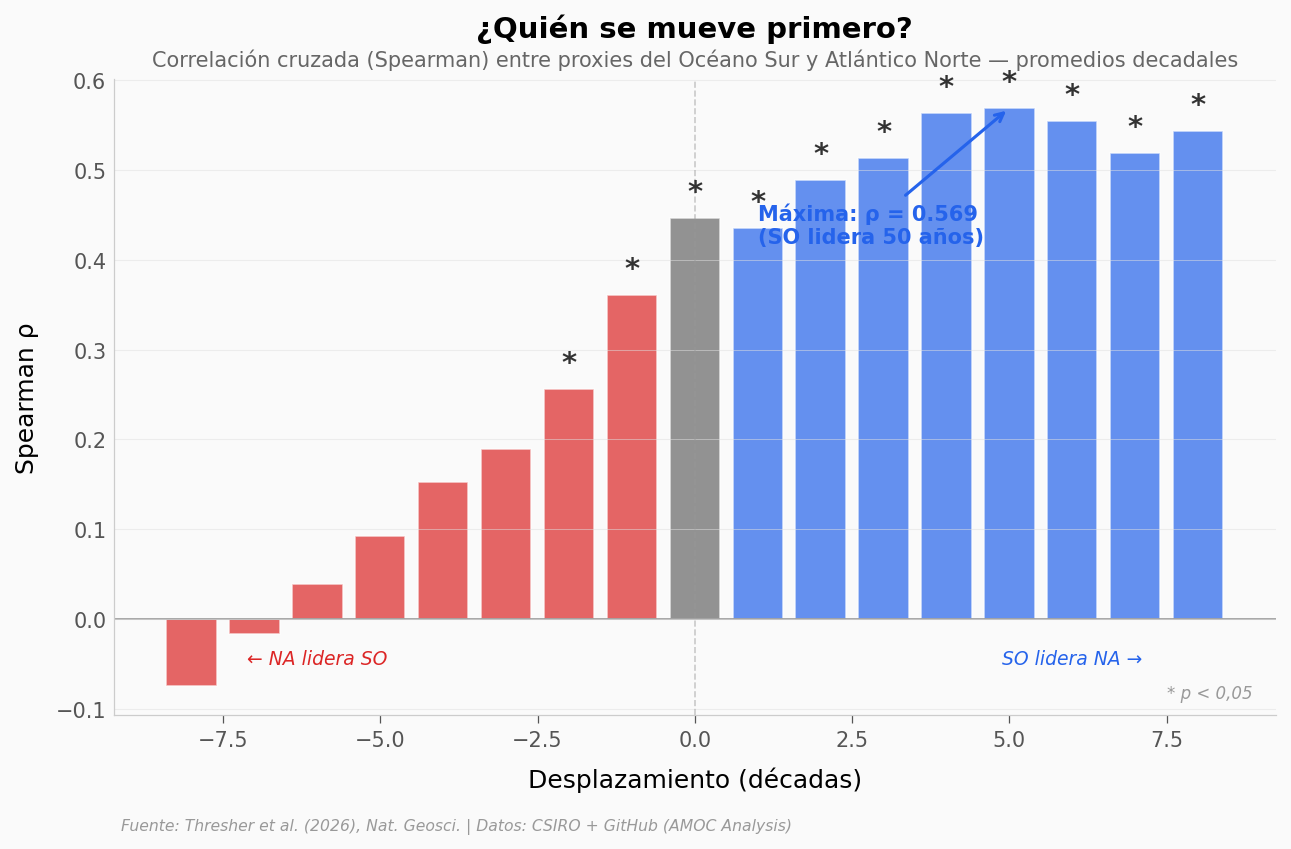

Lag 0 (simultáneo): ρ = 0.446
Lag +5 (SO lidera 50 años): ρ = 0.569
Lag -5 (NA lidera 50 años): ρ = 0.092

Máxima correlación en lag = 5 décadas (ρ = 0.569)


In [4]:
# Promedios por década para reducir ruido
aaiw_dec = df_so.copy()
aaiw_dec['decade'] = (aaiw_dec['year_ce'] // 10) * 10
aaiw_by_dec = aaiw_dec.groupby('decade')['mgca_mmol_mol'].mean().reset_index()

rahm_dec = df_na.copy()
rahm_dec['decade'] = (rahm_dec['year_ce'] // 10) * 10
rahm_by_dec = rahm_dec.groupby('decade')['amoc_index_k'].mean().reset_index()

merged = aaiw_by_dec.merge(rahm_by_dec, on='decade')

# Calcular correlación a cada lag
lags = range(-8, 9)
rhos = []
p_vals = []
for lag in lags:
    shifted = merged.copy()
    shifted['mgca_shifted'] = shifted['mgca_mmol_mol'].shift(lag)
    valid = shifted.dropna()
    if len(valid) > 10:
        rho, p = stats.spearmanr(valid['mgca_shifted'], valid['amoc_index_k'])
        rhos.append(rho)
        p_vals.append(p)
    else:
        rhos.append(np.nan)
        p_vals.append(np.nan)

fig, ax = plt.subplots(figsize=(10, 5.5))

lags_list = list(lags)
colors = [COLOR_SO if l > 0 else COLOR_NA if l < 0 else '#666666' for l in lags_list]
sig = [p < 0.05 for p in p_vals]

bars = ax.bar(lags_list, rhos, color=colors, alpha=0.7, edgecolor='white', linewidth=0.8)

# Mark significance
for i, (l, r, s) in enumerate(zip(lags_list, rhos, sig)):
    if s and not np.isnan(r):
        ax.text(l, r + 0.02, '*', fontsize=14, ha='center', fontweight='bold',
                color='#333333')

# Peak annotation
max_idx = np.nanargmax(rhos)
peak_lag = lags_list[max_idx]
peak_rho = rhos[max_idx]
ax.annotate(f'Máxima: ρ = {peak_rho:.3f}\n(SO lidera {peak_lag}0 años)',
            xy=(peak_lag, peak_rho), xytext=(peak_lag - 4, peak_rho - 0.15),
            fontsize=10, fontweight='bold', color=COLOR_SO,
            arrowprops=dict(arrowstyle='->', color=COLOR_SO, lw=1.5))

ax.axhline(0, color='#999999', linewidth=0.8, zorder=1)
ax.axvline(0, color='#999999', linewidth=0.8, linestyle='--', alpha=0.5)

# Labels
ax.text(-6, -0.05, '← NA lidera SO', fontsize=9, color=COLOR_NA,
        ha='center', style='italic')
ax.text(6, -0.05, 'SO lidera NA →', fontsize=9, color=COLOR_SO,
        ha='center', style='italic')

ax.set_title('¿Quién se mueve primero?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Correlación cruzada (Spearman) entre proxies del Océano Sur y Atlántico Norte — promedios decadales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Desplazamiento (décadas)')
ax.set_ylabel('Spearman ρ')
ax.text(0.98, 0.02, '* p < 0,05', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/lead_lag_correlacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Print key values
print(f"Lag 0 (simultáneo): ρ = {rhos[lags_list.index(0)]:.3f}")
print(f"Lag +5 (SO lidera 50 años): ρ = {rhos[lags_list.index(5)]:.3f}")
print(f"Lag -5 (NA lidera 50 años): ρ = {rhos[lags_list.index(-5)]:.3f}")
print(f"\nMáxima correlación en lag = {peak_lag} décadas (ρ = {peak_rho:.3f})")

El patrón es asimétrico. Cuando el Océano Sur va primero (barras azules, a la derecha), la correlación trepa. Cuando el Atlántico Norte va primero (barras rojas, a la izquierda), se desvanece.

La correlación simultánea es ρ = 0,446 (p = 2,3×10⁻⁵). Pero si damos al Océano Sur una ventaja de 5 décadas, salta a ρ = 0,569 (p = 5,5×10⁻⁸, n = 78 décadas). Leer esto en reversa: cuando el Atlántico Norte "lidera" 5 décadas, la correlación baja a 0,092 (p = 0,42, n = 78) — estadísticamente indistinguible de cero.

Los datos sugieren que el Océano Sur se mueve primero.

## ¿Qué tan inusual es lo que estamos viviendo?

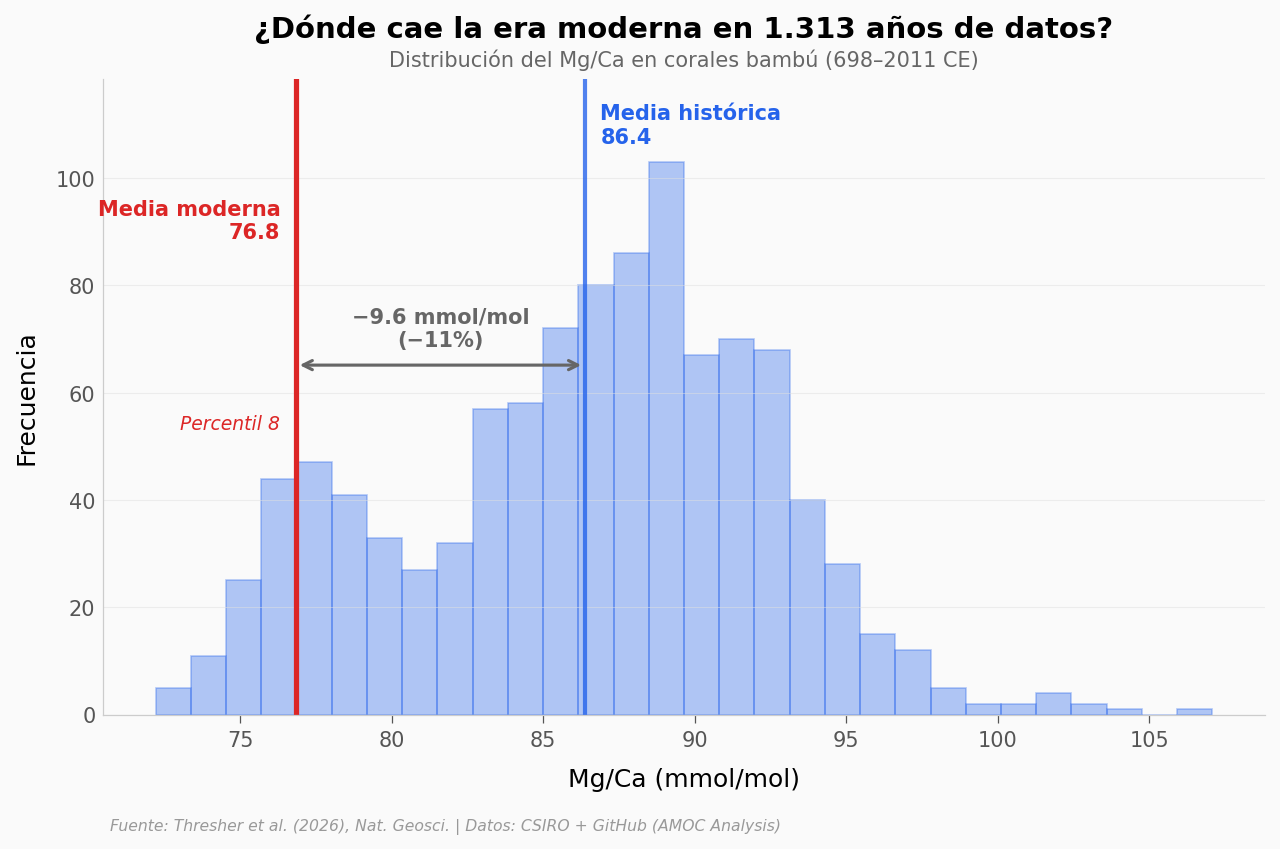

Media histórica: 86.4 mmol/mol
Media moderna (≥1900): 76.8 mmol/mol
Percentil de la media moderna: 8.0


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Histogram of all AAIW values
n, bins, patches = ax.hist(df_so['mgca_mmol_mol'], bins=30, color=COLOR_SO, alpha=0.35,
                           edgecolor=COLOR_SO, linewidth=0.8)

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Full record mean
full_mean = df_so['mgca_mmol_mol'].mean()
ax.axvline(x=full_mean, color=COLOR_SO, linewidth=2, linestyle='-', alpha=0.8)
ax.text(full_mean + 0.5, y_max * 0.9, f'Media histórica\n{full_mean:.1f}',
        fontsize=10, color=COLOR_SO, fontweight='bold')

# Modern mean
modern_mean = df_so[df_so['year_ce'] >= 1900]['mgca_mmol_mol'].mean()
ax.axvline(x=modern_mean, color=COLOR_NA, linewidth=2.5, linestyle='-')
ax.text(modern_mean - 0.5, y_max * 0.75, f'Media moderna\n{modern_mean:.1f}',
        fontsize=10, color=COLOR_NA, fontweight='bold', ha='right')

# Bidirectional arrow
ax.annotate('', xy=(modern_mean, y_max * 0.55), xytext=(full_mean, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = full_mean - modern_mean
ax.text((full_mean + modern_mean) / 2, y_max * 0.58,
        f'−{diff:.1f} mmol/mol\n(−{diff/full_mean*100:.0f}%)',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

# Percentile annotation
pctile = stats.percentileofscore(df_so['mgca_mmol_mol'], modern_mean)
ax.text(modern_mean - 0.5, y_max * 0.45,
        f'Percentil {pctile:.0f}',
        fontsize=9, color=COLOR_NA, ha='right', style='italic')

ax.set_title('¿Dónde cae la era moderna en 1.313 años de datos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Distribución del Mg/Ca en corales bambú (698–2011 CE)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlabel('Mg/Ca (mmol/mol)')
ax.set_ylabel('Frecuencia')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Media histórica: {full_mean:.1f} mmol/mol")
print(f"Media moderna (≥1900): {modern_mean:.1f} mmol/mol")
print(f"Percentil de la media moderna: {pctile:.1f}")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La circulación del Océano Sur ha declinado irregularmente en el último milenio | ✅ | Tendencia negativa significativa (p < 10⁻⁶⁵). Mg/Ca cae de ~87,8 (medieval) a ~76,8 (moderno), Cohen's d = 4,83 |
| La circulación del Océano Sur correlaciona con la AMOC del Atlántico Norte | ✅ | Spearman ρ = 0,446 (p = 2,3×10⁻⁵, n = 83 décadas) en promedios decadales del período compartido (900–1990 CE) |
| Los cambios en el Océano Sur preceden a los del Atlántico Norte | ✅ | La correlación cruzada mejora de ρ = 0,446 (simultáneo) a ρ = 0,569 cuando el Océano Sur lidera 5 décadas. En sentido inverso (NA lidera), cae a 0,092 |
| Ambas circulaciones están en su punto más débil del último milenio | ✅ | AAIW: mínimo en 1972 CE (72,21 mmol/mol). AMOC (Rahmstorf): mínimo en 1991 CE (−0,48 K). Media moderna en percentil 8 |
| El forzamiento local del Atlántico Norte desde 1950 ha agravado la AMOC | ⚠️ | No verificable con estos datos. Requiere comparación con modelos climáticos, fuera del alcance de este notebook |

> **Limitaciones:** (1) El proxy Mg/Ca asume una relación lineal con la temperatura del AAIW — sensibilidad puede variar. (2) Los datos decadales del Fact Sheet provienen de promediar series anuales; la resolución temporal real de los corales varía. (3) El análisis lead-lag con promedios decadales (n = 83 décadas compartidas) tiene potencia estadística moderada. (4) La causalidad SO → NA no se puede establecer solo con correlación cruzada; el paper complementa con modelos que aquí no reproducimos.

## Ahora tú

1. **¿Cuándo empezó la caída?** El decline no es lineal. ¿Puedes identificar el punto de quiebre? Prueba ajustando un modelo con cambio de pendiente (piecewise linear) a la serie del Océano Sur.

2. **¿Hay estacionalidad en la relación?** Los datos de Caesar et al. cubren el período moderno (1871–2016). ¿La correlación SO ↔ NA se mantiene igual en la primera y segunda mitad del siglo XX?

3. **¿Qué pasa con la Antártida?** Los datos de Stenni et al. (2017) tienen temperatura antártica reconstruida por regiones. ¿La región que más se correlaciona con el proxy del Océano Sur es la que esperas?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Se mantiene la correlación SO ↔ NA en subperíodos?

# Primera mitad (900-1450) vs segunda mitad (1450-1990)
periodos = [('900–1450', 900, 1450), ('1450–1990', 1450, 1990)]

for nombre, inicio, fin in periodos:
    sub = merged[(merged['decade'] >= inicio) & (merged['decade'] <= fin)]
    if len(sub) > 10:
        rho, p = stats.spearmanr(sub['mgca_mmol_mol'], sub['amoc_index_k'])
        print(f"{nombre}: ρ = {rho:.3f}, p = {p:.3e}, n = {len(sub)} décadas")

# Puedes probar también por siglo:
# for century in range(900, 2000, 100):
#     sub = merged[(merged['decade'] >= century) & (merged['decade'] < century + 100)]
#     if len(sub) > 5:
#         rho, p = stats.spearmanr(sub['mgca_mmol_mol'], sub['amoc_index_k'])
#         print(f"  Siglo {century}: ρ = {rho:.3f}, n = {len(sub)}")

900–1450: ρ = 0.452, p = 1.378e-02, n = 29 décadas
1450–1990: ρ = 0.692, p = 4.736e-09, n = 55 décadas


---

### Créditos

- **Paper:** Thresher, R., Rintoul, S. & Fallon, S. (2026). Millennial-scale Atlantic overturning circulation led by the Southern Ocean. *Nature Geoscience*. DOI: [10.1038/s41561-026-01959-6](https://doi.org/10.1038/s41561-026-01959-6)
- **Datos primarios:** [CSIRO Data Collection](https://doi.org/10.25919/9dqy-2x95) (CC BY 4.0)
- **Compilación AMOC:** [Cahill et al. (GitHub)](https://github.com/ncahill89/AMOC-Analysis) — datos de Rahmstorf et al. (2015), Caesar et al. (2018)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)
- **Licencia del notebook:** CC BY-SA 4.0